In [460]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier,OneVsRestClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures,label_binarize

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve,auc, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error                      

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid

import sys
from copy import deepcopy

import kagglehub
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams

path = os.path.join(os.getcwd(), 'DataSet', 'AcetyleneData_10_1.txt')

In [461]:
path = os.path.join(os.getcwd(), 'Iris.csv')
df = pd.read_csv(path)
df.drop(['Id'], axis=1, inplace=True)
print(f"Columns name: {df.columns}")
print(f"Species: {df['Species'].value_counts()}")

Columns name: Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
Species: Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [462]:
X = df.drop(['Species'],axis='columns')
X = X[df['Species'] != 'Iris-virginica']
X = sm.add_constant(X)
y = df['Species']
y = y[df['Species'] != 'Iris-virginica']
y = y.map({'Iris-setosa':1,'Iris-versicolor':0})
print(f'Dataset Shape X:{X.shape} y: {y.shape}')

Dataset Shape X:(100, 5) y: (100,)


‘liblinear’ and ‘newton-cholesky’ can only handle binary classification by default.

In [463]:
Logistice = LogisticRegression(random_state=42,penalty='l2',solver='liblinear',max_iter=200,tol=0.001,fit_intercept=True)
res_l2_liblinear = Logistice.fit(X, y)
# Coefficients: shape (n_classes, n_features)
params_fm = pd.Series(res_l2_liblinear.coef_.flatten(), name='coefficients')
# params_fm     = np.hstack([res_l2_liblinear.intercept_, res_l2_liblinear.coef_[0]])


In [464]:
print(f'Totla number of classes: {res_l2_liblinear.classes_.size} and classes {res_l2_liblinear.classes_}')
print(f'Intercept (a.k.a. bias) added to the decision function: {res_l2_liblinear.intercept_}')
print(f'Coefficient of the features in the decision function {res_l2_liblinear.coef_}')
print(f'Number of features: {res_l2_liblinear.n_features_in_}')
print(f'Names of features: {res_l2_liblinear.feature_names_in_}')
print(f'Actual number of iterations for all classes:{res_l2_liblinear.n_iter_}')

Totla number of classes: 2 and classes [0 1]
Intercept (a.k.a. bias) added to the decision function: [0.25001719]
Coefficient of the features in the decision function [[ 0.25001719  0.37293052  1.44414425 -2.2479456  -0.98424938]]
Number of features: 5
Names of features: ['const' 'SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Actual number of iterations for all classes:[5]


### Odd ratio

In [465]:
odds_ratios = np.exp(params_fm)
print("Odds Ratios:\n", odds_ratios)

Odds Ratios:
 0    1.284047
1    1.451983
2    4.238224
3    0.105616
4    0.373720
Name: coefficients, dtype: float64


### Likelihood Ratio Test

The Likelihood Ratio Test (LRT) compares two nested models:
- Full model: includes all predictors.
- Restricted model: excludes one or more predictors.

The Likelihood Ratio Test (LRT) is a powerful method for hypothesis testing in state-space models, especially when comparing nested models with different parameter constraints.

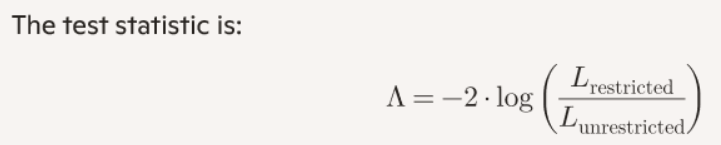

Now we have 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'

So we need to check if 'SepalLengthCm', 'SepalWidthCm' are sufficient to cretae model with > 90% accureacy

So Our full models = {'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'}

reduce models = {'SepalLengthCm', 'SepalWidthCm'}

 Interpretation
- Low p-value (< 0.05): Reject the null hypothesis → the full model fits significantly better.
- High p-value: Fail to reject → the restricted model is sufficient

In [466]:
X_restricted = df[df['Species'] != 'Iris-virginica']
X_restricted = X_restricted.drop(['PetalLengthCm', 'PetalWidthCm','Species'],axis='columns')
X_restricted = sm.add_constant(X_restricted)
Logistice = LogisticRegression(random_state=42,penalty='l2',solver='liblinear',max_iter=200,tol=0.001,fit_intercept=True)
restricted_models = Logistice.fit(X_restricted, y)
# Coefficients: shape (n_classes, n_features)
params = pd.Series(restricted_models.coef_.flatten(), name='coefficients')


In [467]:
model_full       = res_l2_liblinear
model_restricted = restricted_models

#### log-likelihood ratio test by use own formula

In [468]:
probs_full = model_full.predict_proba(X)[:, 1]
probs_restricted = restricted_models.predict_proba(X_restricted)[:, 1]


In [469]:
def log_likelihood(labels, probabilities):
    return np.sum(labels * np.log(probabilities) + (1 - labels) * np.log(1 - probabilities))

In [470]:
ll_full = log_likelihood(y, probs_full)
ll_restricted = log_likelihood(y, probs_restricted)
print(f'll full model:{ll_full} and Restricted modelsd {ll_restricted}')

ll full model:-2.527277719796084 and Restricted modelsd -15.096506214003536


###  log-likelihood by use log_loss in scikit-learn

In [471]:
from sklearn.metrics import log_loss
# Calculate log loss: this gives the NEGATIVE average log-likelihood
avg_log_likelihood_full = log_loss(y, model_full.predict_proba(X)[:, 1])*-100
avg_log_likelihood_restricted = log_loss(y, restricted_models.predict_proba(X_restricted)[:, 1])*-100
print(f'll full model:{avg_log_likelihood_full} and Restricted modelsd {avg_log_likelihood_restricted}')

ll full model:-2.527277719796084 and Restricted modelsd -15.096506214003536


### Calculate LRT Statistic and p-value

In [472]:
lr_stat = -2 * (ll_restricted - ll_full)
df_diff = X.shape[1] - X_restricted.shape[1]
p_value = chi2.sf(lr_stat, df_diff)

print(f"LR stat: {lr_stat:.4f}, p-value: {p_value:.4f}, df diff: {df_diff}")

if p_value < 0.05: 
    print('Reject the null hypothesis → the full model fits significantly better.')
else:
    print('Fail to reject → the restricted model is sufficient') 

LR stat: 25.1385, p-value: 0.0000, df diff: 2
Reject the null hypothesis → the full model fits significantly better.


In [473]:
pred_probs_full = model_full.predict(X)
pred_probs_full_lable = (pred_probs_full > 0.9).astype(int)
pred_probs_restricted = model_restricted.predict(X_restricted)
accuracy_full = (pred_probs_full == y).mean()
accuracy_restricted = (pred_probs_restricted == y).mean()
print(f'accureacy of full model {accuracy_restricted}, accureacy of restricted models {accuracy_restricted}')

accureacy of full model 0.99, accureacy of restricted models 0.99


# Testing Goodness of Fit with Deviance

1. Deviance and Pseudo R-squared
- Deviance: Measures how well the model fits compared to a saturated model.
  - Null deviance measures the variability in a model without any predictor
    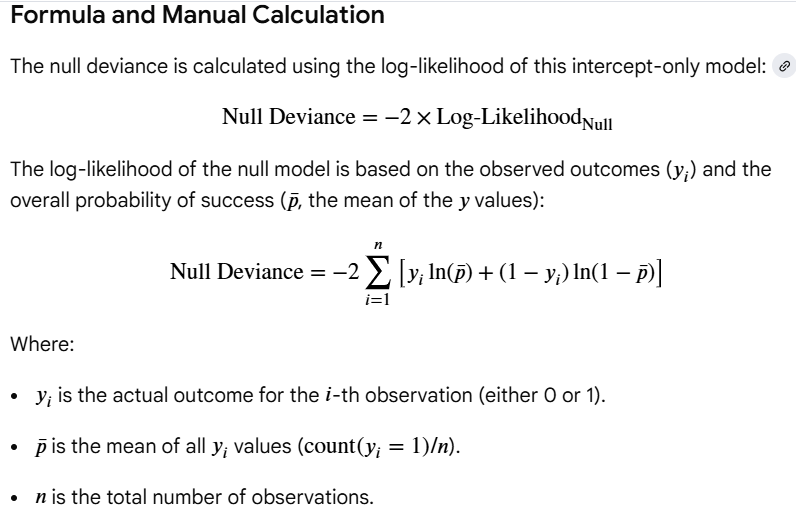
  - residual deviance measures the variability left after adding predictors to the model
- Lower deviance → better fit.
- Pseudo R² (e.g., McFadden’s R²):


#### Null Deviance

In [474]:
# Null Deviance is very tricky in Scikit lern
# However in Statemodels its get by fir the full models & get res.null_deviance

# Assuming 'y' is a numpy array of your binary outcomes
# Calculate the mean of y (the null model's single predicted probability)
y_bar = np.mean(y)
# Create an array of the null predictions (all equal to the mean)
y_null_pred = [y_bar] * len(y)
# Calculate the log-likelihood sum using log_loss (note: normalize=False returns the sum)
# log_loss inherently calculates the negative log-likelihood
# The result needs to be multiplied by 2 to match the deviance definition
ll_null = log_loss(y, y_null_pred, normalize=False) * -1

null_deviance_manual = -2 * ll_null # or simply 2 * log_loss(..., normalize=False)
print(f"Null Deviance (manual calc): {null_deviance_manual:.4f}")


Null Deviance (manual calc): 138.6294


#### Residual Deviance

In [475]:

# Calculate Residual Deviance: -2 * sum of log-likelihoods
# Note: log_loss function uses the mean, so multiply by number of samples to get sum
residual_deviance_full_models = 2 * len(y) * avg_log_likelihood_full
residual_deviance_restricted_models = 2 * len(y) * avg_log_likelihood_restricted

#### McFadden's R-squared

McFadden's R-squared (\(\rho ^{2}\)) is a popular measure used to assess the **goodness-of-fit** for logistic regression models. It is a "pseudo" R-squared because it cannot be interpreted the same way as the \(R^{2}\) in linear regression, but it provides a useful way to compare the explanatory power of different models on the same data.

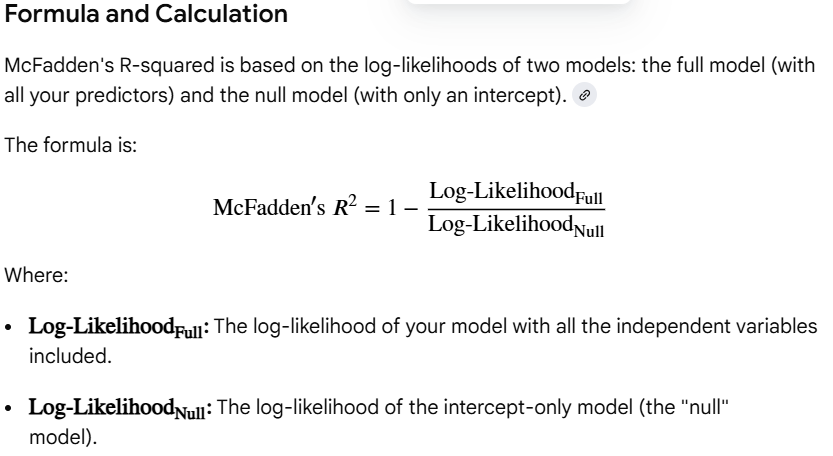

In statsmodels you can calulate it by

- Access the R-squared value directly
- mc_fadden_r2 = model.prsquared

###### Calculate McFadden's R-squared Manually

mc_fadden_r2_manual = 1 - (ll_full / ll_null)

In [476]:
mc_fadden_r2_manual = 1 - (avg_log_likelihood_full / ll_null)
print(f"\nMcFadden's R-squared (manual): {mc_fadden_r2_manual:.4f}")


McFadden's R-squared (manual): 0.9635


#### Explanation and Interpretation of the Result

**Values closer to 1 i.e. 0.99 in our case**: indicate that the model with predictors provides a significant improvement in fit over the null model (meaning the predictors are useful).

***but if Values closer to 0*** suggest that the model with predictors is not much better than just using the average probability (the null model).

#### ***Note:  A model with a higher McFadden's R-squared is generally preferred.***

In [477]:
print(f"Null Deviance: {null_deviance_manual:.4f}")
print(f"Residual Deviance full models: {abs(residual_deviance_full_models):.4f}")
print(f"Residual Deviance Restricted models: {abs(residual_deviance_restricted_models):.4f}")
if abs(residual_deviance_restricted_models) < abs(residual_deviance_full_models):
    print('Conclude Restricted models are the good predictor in compaire full models')
else:
    print('Full models are the Good predictor in compaire restricted models')
print(f"McFadden's R-squared: {mc_fadden_r2_manual:.4f}")

Null Deviance: 138.6294
Residual Deviance full models: 505.4555
Residual Deviance Restricted models: 3019.3012
Full models are the Good predictor in compaire restricted models
McFadden's R-squared: 0.9635


AIC and BIC
- AIC (Akaike Information Criterion) and BIC (Bayesian Information Criterion) penalize complexity.
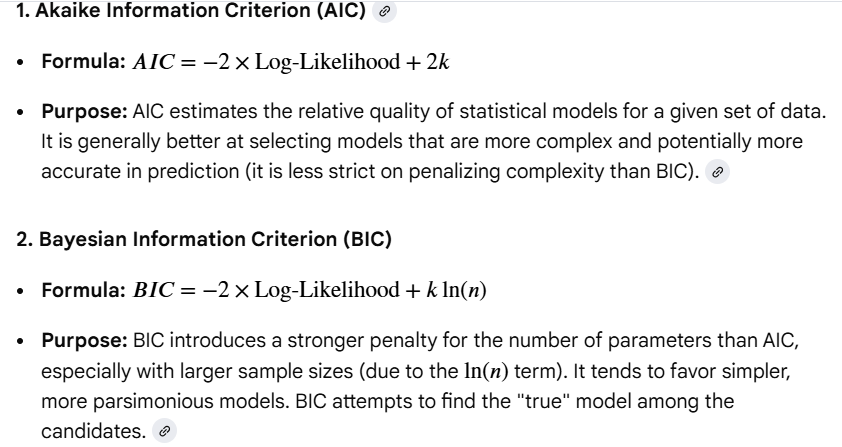

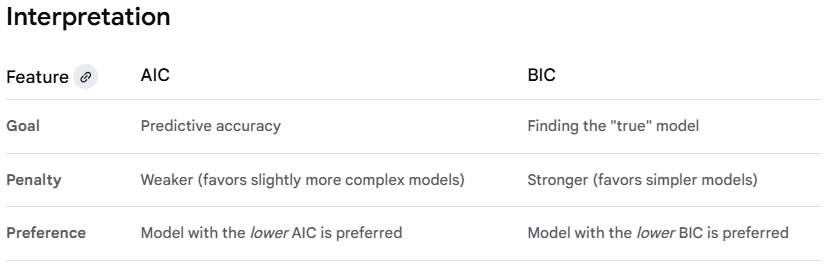


In [478]:
n_sample_size = y.shape[0]

# Number of parameters (coefficients + intercept)

k_num_parameters_full_models = X.shape[1] + 1
k_num_parameters_restricted_models = X_restricted.shape[1] + 1

print(f'Full models Sample Size: {n_sample_size} parameters {k_num_parameters_full_models}')
print(f'restricted models Sample Size: {n_sample_size} parameters {k_num_parameters_restricted_models}')

aic_full_models = 2 * (k_num_parameters_full_models - 2) * avg_log_likelihood_full
bic_full_models = np.log(n_sample_size) * (k_num_parameters_full_models - 2) * avg_log_likelihood_full


print(f'AIC full models: {aic_full_models}')
print(f'BIC full models: {bic_full_models}')

aic_restricted_models = 2 * (k_num_parameters_restricted_models - 2) * avg_log_likelihood_restricted
bic_restricted_models = np.log(n_sample_size) * (k_num_parameters_restricted_models - 2) * avg_log_likelihood_restricted

print(f'AIC restricted models: {aic_restricted_models}')
print(f'BIC restricted models: {bic_restricted_models}')

# Model with Lower AIC & BIC are preffered
if abs(bic_restricted_models) < abs(aic_full_models):
    print('Restricted Models are the Lower AIC. So we can conclude restricted models can better explaine!!!')
else:
    print('Full models have lower AIC score. So we can choose Full model have better expalanmtions')

if abs(bic_restricted_models) < abs(bic_full_models):
    print('Restricted Models are the Lower BIC. So we can conclude restricted models can better explaine!!!')
else:
    print('Full models have lower BIC score. So we can choose Full model have better expalanmtions')


Full models Sample Size: 100 parameters 6
restricted models Sample Size: 100 parameters 4
AIC full models: -20.21822175836867
BIC full models: -46.554176027667566
AIC restricted models: -60.386024856014146
BIC restricted models: -139.0439606586261
Full models have lower AIC score. So we can choose Full model have better expalanmtions
Full models have lower BIC score. So we can choose Full model have better expalanmtions


#### Testing Hypotheses on Subsects of Parameters Using Deviance

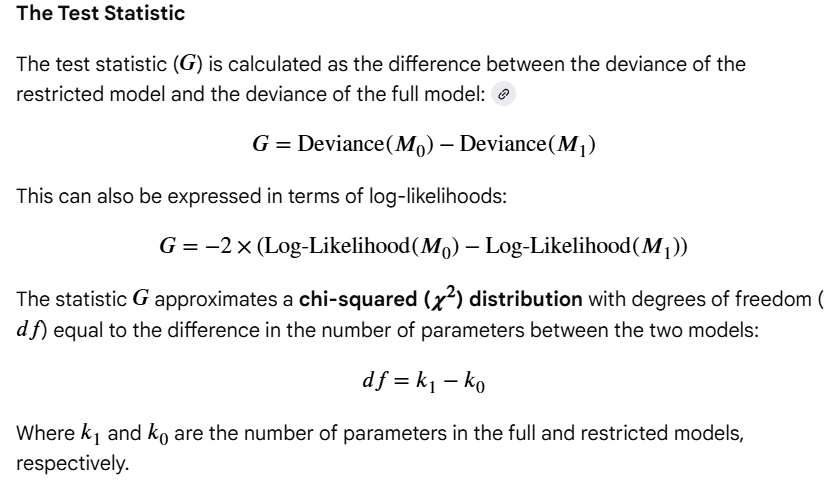
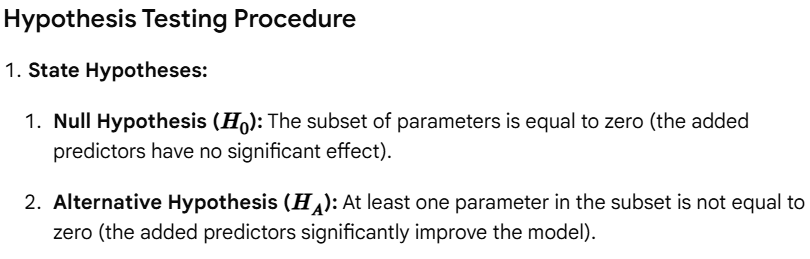

residual_deviance_full_models = D(β1 β2 β3 β4|β0)

residual_deviance_restricted_models = D(β1 β2 |β0)

Example 1: 

- Similarly we can calculate effect of β1 when β2 β3 already given

- D(β1|β0 β2 β3) = D(β0 β2 β3) - D(β1β0)


In [479]:
# Calculate the test statistic (G)
G_statistic = residual_deviance_full_models - residual_deviance_restricted_models

# Calculate degrees of freedom
dof_Full_vs_Restricted = k_num_parameters_full_models - k_num_parameters_restricted_models 

# Calculate the p-value using the chi-squared distribution
p_value = 1 - chi2.cdf(G_statistic, dof_Full_vs_Restricted)

print(f"G Statistic (Deviance Difference): {G_statistic:.4f}")
print(f"Degrees of Freedom: {dof_Full_vs_Restricted}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print('Conclusion: found p-value < 0.05, reject H0 and conclude the added features improve the model')
else:
    print('fail to reject H0,  indicating the subset of parameters does not offer a significant improvement over the simpler model.')

G Statistic (Deviance Difference): 2513.8457
Degrees of Freedom: 2
P-value: 0.0000
Conclusion: found p-value < 0.05, reject H0 and conclude the added features improve the model


### Tests on Individual Model Coefficients

#### Wald Statice test for indivisulal cofficient

**Wald statistic** test is a method used in logistic regression to determine the statistical significance of individual predictor variables (coefficients) or groups of predictors.

The Wald test is an approximation that uses the estimated coefficient and its standard error to form a test statistic, which asymptotically follows a **chi-squared (χ2)**  distribution under the null hypothesis.

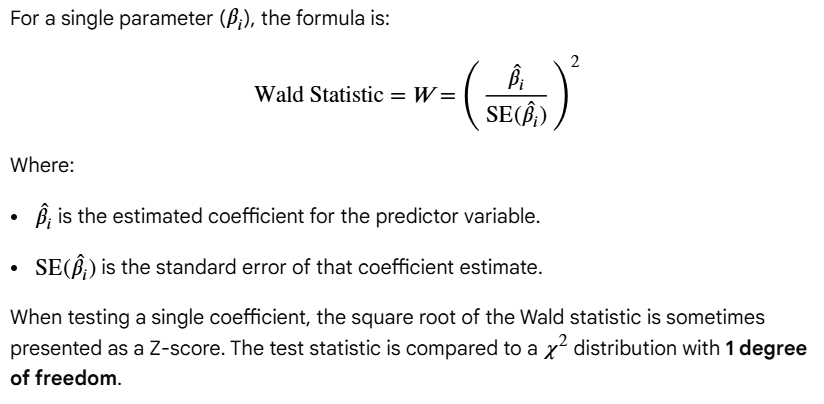

#### Explanation and Interpretation of the Result

- Null Hypothesis H0: The coefficient (βj) is zero (the predictor has no effect on the outcome).Alternative    
- Hypothesis (Hα): The coefficient is not zero (the predictor has a significant effect).

### Interpretation Steps:

- High Wald Statistic / Low P-value: A large Wald statistic corresponds to a small p-value (typically 
p < 0.05). This indicates **strong evidence against the null hypothesis**.

  - Conclusion: You reject the null hypothesis and conclude that the predictor variable is statistically significant and should be retained in the model.

- Low Wald Statistic / High P-value: A small Wald statistic corresponds to a large p-value. This suggests that the coefficient is not significantly different from zero.
  - Conclusion: You fail to reject the null hypothesis, implying the variable may not contribute significantly to the model and could potentially be removed.

Steps for wald statices

- Calculate Hessian matrix from ll. Hessian are evaluated at the maximum likelihood estimators ß = b
  
  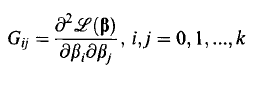

large-sample approximate covariance matrix of the regression coefficients is

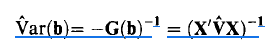

The square roots of the diagonal elements of this covariance matrix are the large-sample estimated standard errors of the regression coefficients, so the test statistic for the null hypothesis in

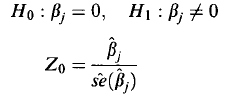

The reference distribution for this statistic is the standard normal distribution. Some computer packages square the Z0 statistic and compare it to a chi-square distribution with one degree of freedom.

In [480]:
# Manually calculate Wald statices, based on abover formulas

# Calculate predicted probabilities
predictions_full_models = res_l2_liblinear.predict_proba(X)[:, 1]

# Calculate weights matrix W (diagonal matrix of p * (1-p))
weights = np.diag(predictions_full_models * (1 - predictions_full_models))

# Variance 
Variance = y.shape[0]*np.diag(predictions_full_models * (1 - predictions_full_models))

# Calculate the Hessian H = -X_design.T @ W @ X_design
# Use XTX product for matrix multiplication
XTX_product = X.T @ weights @ X
hessian = -XTX_product

# Calculate Covariance Matrix as the inverse of the negative Hessian
# Use pseudo-inverse for stability in case of singularities
try:
    cov_matrix = np.linalg.pinv(-hessian)
except np.linalg.LinAlgError:
    print("Cannot invert matrix to find standard errors.")
    cov_matrix = None

if cov_matrix is not None:
    # Standard errors are the square root of the diagonal elements
    std_errors_cofficient = np.sqrt(np.diag(cov_matrix))
    #print("\nStandard Errors (Manual Sklearn Calc):\n", std_errors_cofficient)
    dfStdErr = pd.DataFrame({'coff':params_fm,'std_err':std_errors_cofficient})
    dfStdErr['wald_state'] = np.square(params_fm/std_errors_cofficient)
    dfStdErr['Z_Score'] = np.sqrt(dfStdErr['wald_state'])
    dfStdErr['P>|z|'] = 0.05 > abs(dfStdErr['Z_Score'])
    print(dfStdErr)   
    print('Note: if P>|z| i.e. this is z score less than 0.05\n'
           'we conclude that regressor Xj is a statistically \n'
           'significant predictor in the model')

       coff   std_err  wald_state   Z_Score  P>|z|
0  0.250017  8.540946    0.000857  0.029273   True
1  0.372931  2.603948    0.020511  0.143217  False
2  1.444144  2.249319    0.412211  0.642036  False
3 -2.247946  2.540716    0.782816  0.884769  False
4 -0.984249  5.199681    0.035831  0.189290  False
Note: if P>|z| i.e. this is z score less than 0.05
we conclude that regressor Xj is a statistically 
significant predictor in the model


### Confidence Intervals

It is straightforward to use Wald statistics to construct confidence intervals in logistic regression.

An approximate 100(1 - α) percent confidence interval on the yth model coefficient is

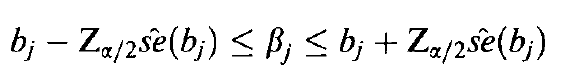


#### Interpretation of the Confidence Intervals

- For a 95% CI, we are 95% confident that the true population parameter (the true coefficient βj) lies within the calculated range.
- **Significance Test**: If the confidence interval does not contain zero, the predictor is considered statistically significant at the corresponding alpha level (e.g., a 95% CI not containing zero means the p-value is < 0.05). This is equivalent to performing the Wald hypothesis test.

You can see manually calculated probilities are @ very marginal diffrence

In [481]:
# Firt we calculate predected probability manually
probs_full = res_l2_liblinear.predict_proba(X)[:, 1]
probs_full_manually = 1 / (1 + np.exp(-np.dot(X, params_fm)))
dfProbs = pd.DataFrame({'p_full':np.round(probs_full,2),'p_man_fuull':np.round(probs_full_manually,2),
                        'margina_diff':np.round(probs_full_manually,2)- np.round(probs_full,2)})
print(dfProbs.head())

   p_full  p_man_fuull  margina_diff
0    0.98         0.98          0.00
1    0.96         0.96          0.00
2    0.98         0.97         -0.01
3    0.96         0.95         -0.01
4    0.99         0.98         -0.01


#### We have already calculated wald statices in above. So we can use that result


In [482]:
alpha = 0.05
Z_critical = norm.ppf(1 - alpha/2) # Z_critical for 95% CI is ~1.96

dfStdErr['[0.025'] = dfStdErr['coff'] - (Z_critical * dfStdErr['std_err'])
dfStdErr['0.975]'] = dfStdErr['coff'] + (Z_critical * dfStdErr['std_err'])
print(dfStdErr)



       coff   std_err  wald_state   Z_Score  P>|z|     [0.025     0.975]
0  0.250017  8.540946    0.000857  0.029273   True -16.489929  16.989963
1  0.372931  2.603948    0.020511  0.143217  False  -4.730713   5.476574
2  1.444144  2.249319    0.412211  0.642036  False  -2.964440   5.852728
3 -2.247946  2.540716    0.782816  0.884769  False  -7.227657   2.731765
4 -0.984249  5.199681    0.035831  0.189290  False -11.175436   9.206937


#### Similary we can calculate confidance interval for Odds Ratio

TODO

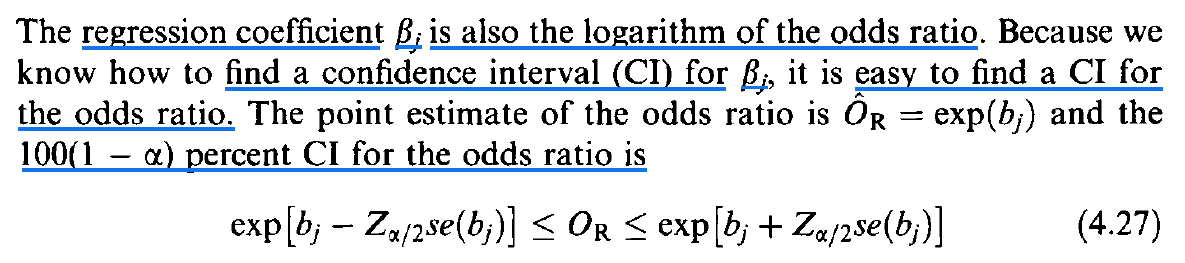

### CI of linear predicitor

The estimated variance of the linear predictor at this point is

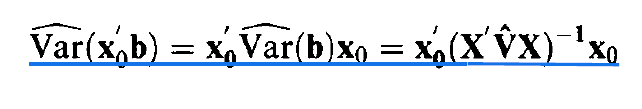

where

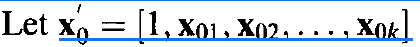

V ̂   = (V cap) Covariance matrix, We have already calculate above.

lOO(l-α) percent CI on the linear predictor is

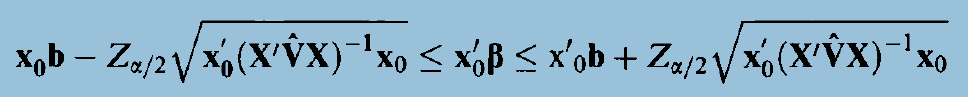

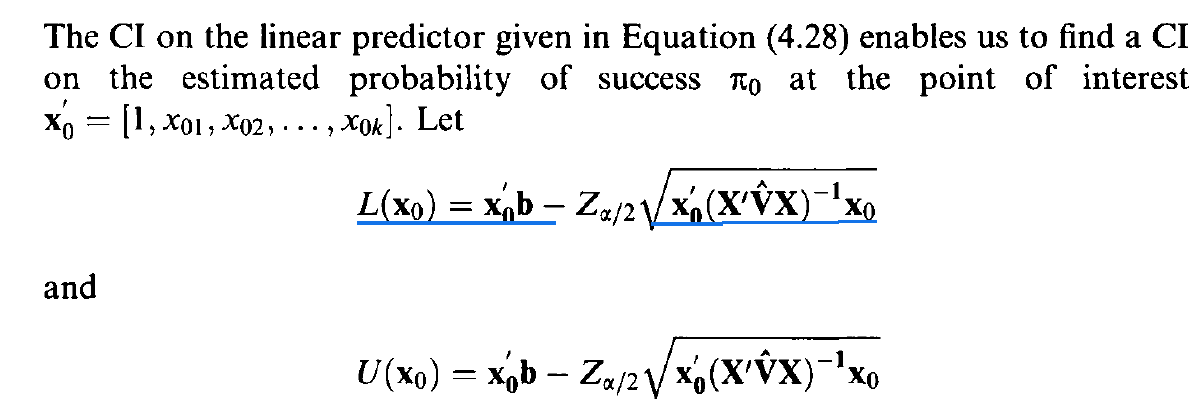

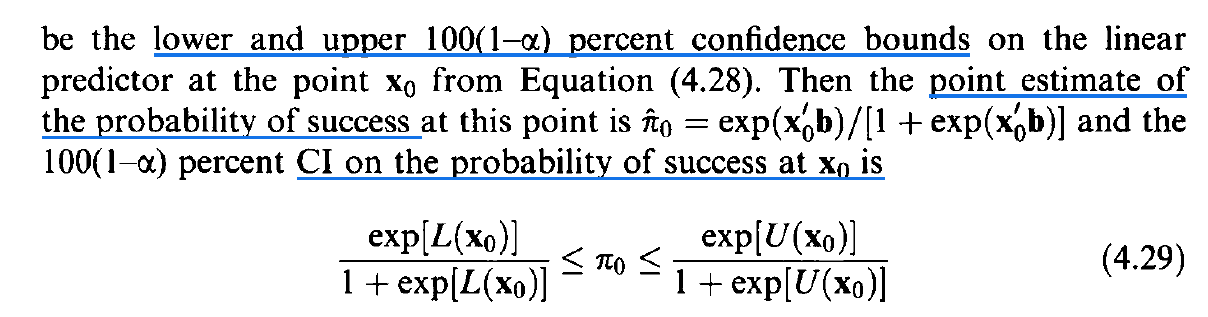

# Lack-of-Fit Tests in Logistic Regression

TODO

lack-of-fit represents what we could have fit to the data but chose not to fit. The deviance test outlined in the previous section is such a test since it formally tests the current logistic regression model against the
saturated model. This approach is most valuable for comparing nested models with grouped data.

Pearson chi-square goodness-of-fit, which compares the observed to expected counts, is

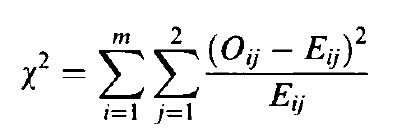

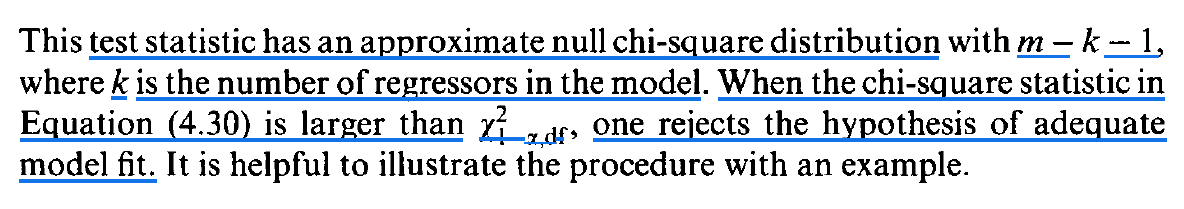

### Assessing Model Fit When Continuous Regressors are Present

Hosmer and Lemeshow (1989) proposed an alternative chi-square test

### Hosmer-Lemeshow test

The Hosmer-Lemeshow statistic is widely available in most statistical software packages that accommodate generalized linear models. While the Hosmer-Lemeshow statistic is appropriate for assessing fit from logistic regression models involving continuous regressor variables, it has been shown to have low power when there are both continuous and categorical variables in the logistic regression model.

### Assessing Model Fit When Both Categorical and Continuous Regressors are Present

Pulkstenis and Robinson (2002) teset

Pulkstenis and Robinson (2002) propose two statistics that combine the strengths of the Pearson chi-square and deviance tests with a modification for continuous covariates similar to that provided by the Hosmer-Lemeshow
procedure. The Pulkstenis-Robinson procedures utilize a two-level sub grouping within each categorical covariate pattern based on fitted probabilities within the specific covariate patterns.

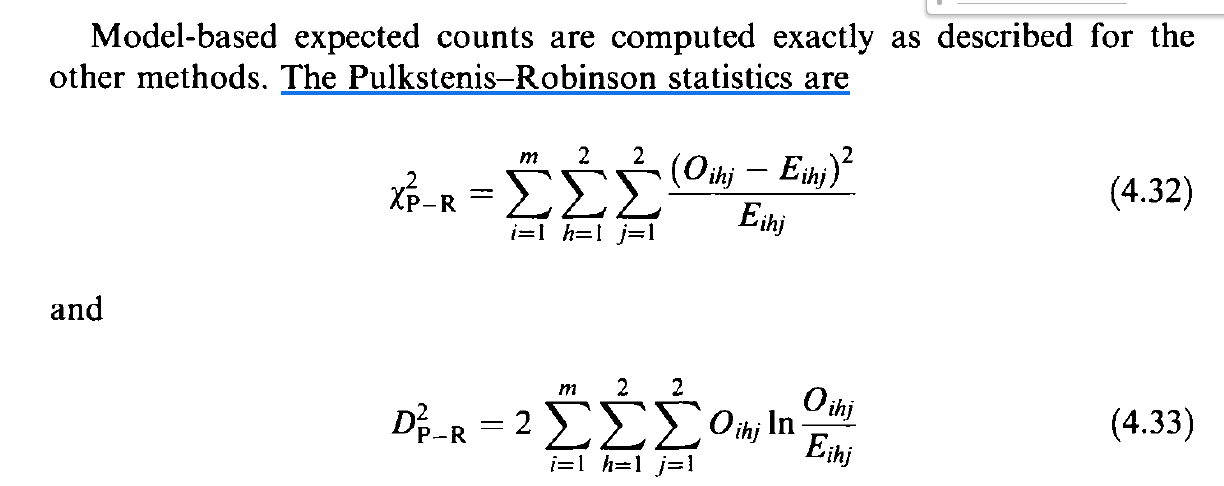


get the influence measure

Comparison

- llf, deviance and pearson_chi2

Likelihood Ratio type test

### Confusions matrix

### Plots
#### Diagnostic Checking in Logistic Regression
We extract information that will be used to draw some interesting plots:

### The ordinary residuals are defined as usua

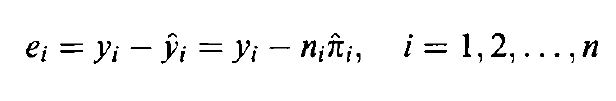

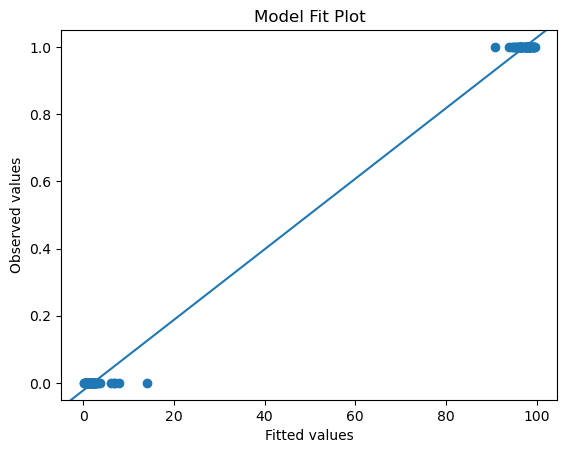

In [483]:
# ei = y - n*p
from statsmodels.graphics.api import abline_plot
yhat = X.shape[0]*probs_full
ordinary_residuals = y - yhat
fig, ax = plt.subplots()
ax.scatter(yhat, y)
line_fit = sm.OLS(y, sm.add_constant(yhat, prepend=True)).fit()
abline_plot(model_results=line_fit, ax=ax)


ax.set_title('Model Fit Plot')
ax.set_ylabel('Observed values')
ax.set_xlabel('Fitted values');

#### deviance residua

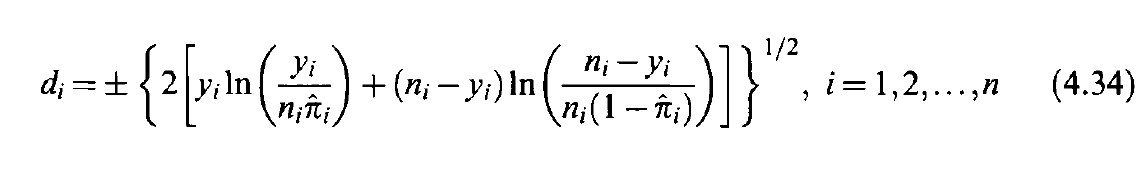

where
- yi = is the actual observed outcome (0 or 1).
- πi is the predicted probability of success for that observation.
- ln is the natural logarithm.
-  The sum of the squared deviance residuals equals the model's total residual deviance.

In [484]:
# Manual calculation function for deviance residuals
def calculate_deviance_residuals(y_true, y_pred_proba):
    # Ensure probabilities are within a valid range to avoid log(0) issues
    p = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    
    # Calculate the individual log-likelihood terms
    log_lik_terms = y_true * np.log(p) + (1 - y_true) * np.log(1 - p)
    
    # Calculate the squared residual part: -2 * log-likelihood term
    squared_res = -2 * log_lik_terms
    
    # Calculate the sign: sign(observed - predicted)
    signs = np.sign(y_true - y_pred_proba)
    
    # Combine sign and square root
    deviance_res = signs * np.sqrt(squared_res)
    
    return deviance_res

In [485]:
manual_residuals = calculate_deviance_residuals(y, probs_full)

print("First 5 Manual Deviance Residuals:")
print(manual_residuals[:5])

# Verify the sum of squares
print(f"\nSum of squared manual residuals: {np.sum(manual_residuals**2):.4f}")

First 5 Manual Deviance Residuals:
0    0.180190
1    0.267057
2    0.215097
3    0.293456
4    0.170862
Name: Species, dtype: float64

Sum of squared manual residuals: 5.0546


### Pearson residual

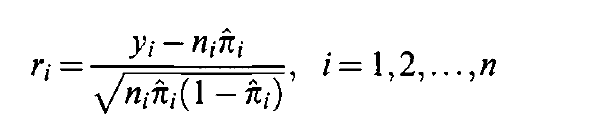

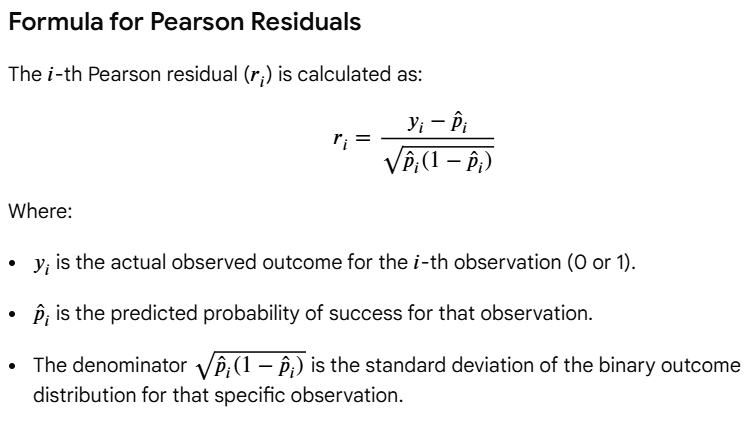

**Key property**: The sum of the squared Pearson residuals approximately equals the Pearson Chi-squared goodness-of-fit statistic for the model.

Pearson residuals are standardized differences between observed and expected values, making them easier to interpret than raw residuals.

Interpretation:

- **Values near zero**: Indicate that the observation is well-predicted by the model.
- **Large absolute values**: Indicate that the observation is poorly predicted or is a potential outlier.
- **Rule of Thumb**: As with standard normal values, Pearson residuals with an absolute value typically greater than 2 or 3 are considered large enough to warrant investigation as potential outliers or influential points.

In [486]:
# 2. Define a function for manual calculation
def calculate_pearson_residuals(y_true, y_pred_proba):
    # Ensure probabilities are within valid range to prevent division by zero
    p = np.clip(y_pred_proba, 1e-15, 1 - 1e-15)
    
    # Calculate the numerator (observed - expected)
    numerator = y_true - p
    
    # Calculate the denominator (standard deviation of the expected outcome)
    denominator = np.sqrt(p * (1 - p))
    
    # Calculate the residual
    pearson_res = numerator / denominator
    
    return pearson_res

In [493]:
manual_pearson_residuals = calculate_pearson_residuals(y, probs_full)

# 3. Display the first 5 results
print("First 5 Manual Pearson Residuals:")
print(manual_pearson_residuals[:5])
print('Check for  warrant investigation')
if len(manual_pearson_residuals[manual_pearson_residuals > 2].index):
    print('Identifying Outliers, Required to warrant investigation for this index')
    print(manual_pearson_residuals[manual_pearson_residuals > 2].index)
else:
    print('Not any Identifying Outliers in entire dataset')


First 5 Manual Pearson Residuals:
0    0.127932
1    0.190534
2    0.152980
3    0.209759
4    0.121260
Name: Species, dtype: float64
Check for  warrant investigation
Not any Identifying Outliers in entire dataset


### hat matrix analog for logistic regression

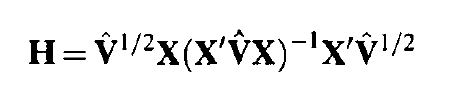

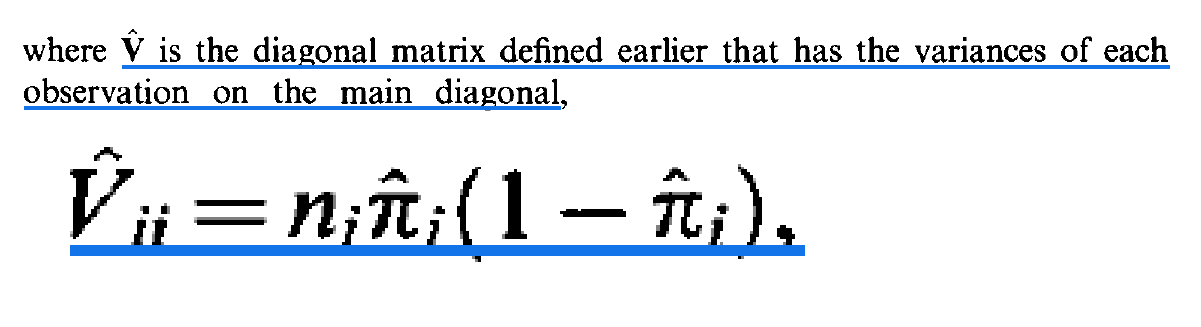

In [500]:
# Calculate variance weights (scalar per-observation): w_i = p_i * (1 - p_i)
# Use X.values to work with numpy arrays (avoids DataFrame indexing issues)
X_design = X.values
n_sample_size = X_design.shape[0]

w_vector = probs_full * (1 - probs_full)   # do NOT multiply by n here for hat values
W = np.diag(w_vector)

# Calculate the inner part: (X^T * W * X)^-1
xtwx = X_design.T @ W @ X_design
# use pseudo-inverse for numerical stability
xtwx_inv = np.linalg.pinv(xtwx)

# Calculate the diagonal elements h_i (leverage)
hat_values_manual = np.zeros(n_sample_size)

for i in range(n_sample_size):
    x_i = X_design[i, :].reshape(-1, 1)  # numpy row -> column vector
    wi = w_vector[i]                     # scalar weight for observation i
    # h_i = w_i * x_i^T * (X^T W X)^-1 * x_i
    hat_values_manual[i] = float(wi * (x_i.T @ xtwx_inv @ x_i))

print("\nFirst 10 Manual Hat Values (Leverage):")
print(hat_values_manual[:10])
print(f"\nSum of manual hat values: {np.sum(hat_values_manual):.4f}")


First 10 Manual Hat Values (Leverage):
[0.018084   0.04048197 0.01996354 0.04775511 0.0180423  0.04585638
 0.04141502 0.02236361 0.06862505 0.05044884]

Sum of manual hat values: 5.0000


C:\Users\TODO\AppData\Local\Temp\ipykernel_13684\3982289075.py:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  hat_values_manual[i] = float(wi * (x_i.T @ xtwx_inv @ x_i))


In [501]:
# 3. Manually calculate the Standardized Pearson Residuals
# Formula: r_i* = r_i / sqrt(1 - h_i)
standardized_pearson_residuals = manual_pearson_residuals / np.sqrt(1 - hat_values_manual)

# 4. Display results
print("First 5 Standardized Pearson Residuals:")
print(standardized_pearson_residuals[:5])

# Verify with built-in method (rstandard(type="pearson") is used in R, but we use the formula directly)
# Statsmodels does not have a direct attribute for this specific statistic, but calculates them internally

First 5 Standardized Pearson Residuals:
0    0.129105
1    0.194511
2    0.154531
3    0.214954
4    0.122369
Name: Species, dtype: float64
